In [83]:

import astropy.units as u

R = 8.314472 * u.J / (u.mol * u.K)
T_init = 273.15 * u.K
P_init = 264.96 * u.Pa
N_A = 6.022140e23  / u.mol
n = (P_init * N_A / (R * T_init)).to(u.m**-3)

k_B = 1.380658e-23 * u.m**2 * u.kg / (u.s**2 * u.K)
n_2 = (P_init / (k_B * T_init)).to(u.m**-3)

print(n)
print(n_2)

7.025791910216458e+22 1 / m3
7.025754926017738e+22 1 / m3


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# parameters for hard sphere interactions
omega = 0.5
# corresponds to isotropic scattering
alpha = 1
mu_inf_mu_1 = 1.016034
mu_1_mu_inf =  1 / mu_inf_mu_1
mu_ref = 2.117e-5

m = 66.3e-27

k_B = 1.380658e-23
T_init = 273.15
numerator =  5 * (alpha + 1) * (alpha + 2) * np.sqrt(m * k_B * T_init / np.pi)
denominator = 4 * alpha * (5 - 2 * omega) * (7 - 2 * omega) * mu_ref * (mu_1_mu_inf)
d_ref =  np.sqrt(numerator / denominator)
print(f"Reference Diameter : {d_ref:0.4E}")
pressure = 264.96
N_A = 6.022140e23
R = 8.314472
density = pressure * N_A / (R * T_init)
lambda_0 =  1 / (np.sqrt(2) * np.pi * d_ref**2 * density)
print(f"Lambda_0           : {lambda_0:0.4E}")

L = 1e-3
cell_counts = 200
dx = L / cell_counts
dx_tilde = dx / lambda_0
print(f"Delta x tilde      : {dx_tilde:0.4E}")

c_0 = np.sqrt(2 * k_B * T_init / m)
print(f"c_0                : {c_0:0.4E}")
dt = 5e-8
dt = 2.5e-8
dt = dt / 2
t_0 = lambda_0 / c_0

dt_tilde = dt / t_0
print(f"Delta t tilde      : {dt_tilde:0.4E}")

Reference Diameter : 3.6579E-10
Lambda_0           : 2.3943E-05
Delta x tilde      : 2.0883E-01
c_0                : 3.3729E+02
Delta t tilde      : 1.7609E-01


In [86]:
def q_wall(dt_tilde, dx_tilde):
  factor = 1 + 0.0281 * dt_tilde**2
  factor += 0.0399 * dx_tilde**2
  factor -= 0.0011 * dx_tilde**4
  factor -= 0.0170 * dt_tilde**2 * dx_tilde**2
  factor += 0.0083 * dt_tilde**4 * dx_tilde**2
  return 1512 * factor

expected_q_wall = q_wall(dt_tilde, dx_tilde)

In [87]:
def trueSolution(x, T_mid, delta_T):
  T_min = T_mid - delta_T / 2.0
  return T_min + (delta_T) / (x.max() - x.min()) * x

In [88]:
#folder = "dt_5e-8"
folder = "./"

In [89]:
  # temperature_data = pd.read_csv(f"{folder}/real_csv_final_average_temperature_100001.csv")
  # x_vals = temperature_data["x"] * 1e3
  # delta_T = 100
  # plt.figure()
  # plt.plot(x_vals, temperature_data["time_averaged_temperature"], label="DSMC")
  # plt.plot(x_vals, trueSolution(x_vals, T_init, delta_T), 'k--', label="Continuum" )
  # plt.legend()
  # plt.xlabel("X (mm)")
  # plt.ylabel("Temperature (K)")
  # #plt.axvline(0.5)
  # plt.show()


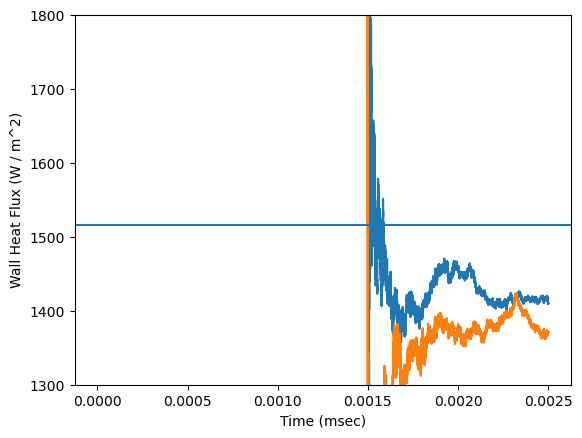

In [90]:
#data = pd.read_csv(f"{folder}/real_csv.csv")
data = pd.read_csv("real_csv.csv")
plt.figure()
plt.plot(data["time"], data["left_heat_flux"])
plt.plot(data["time"], np.abs(data["right_heat_flux"]))
plt.ylim(top=1800, bottom=1300)
plt.axhline(expected_q_wall)
plt.xlabel("Time (msec)")
plt.ylabel("Wall Heat Flux (W / m^2)")
plt.show()

In [91]:
heat_flux_left = data["left_heat_flux"].to_numpy()[-1]
heat_flux_right = data["right_heat_flux"].to_numpy()[-1]
heat_flux_mean = (heat_flux_left + np.abs(heat_flux_right)) / 2

print(f"Expected wall heat flux   : {expected_q_wall:0.2f} W / m^2")
print(f"Mean wall flux            : {heat_flux_mean:0.2f} W / m^2")
print(f"Mean wall flux error      : {np.abs(heat_flux_mean - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Left wall heat flux       : {heat_flux_left:0.2f} W / m^2")
print(f"Left wall heat flux error : {np.abs(heat_flux_left - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Right wall heat flux      : {np.abs(heat_flux_right):0.2f} W / m^2")
print(f"Left wall heat flux error : {np.abs(np.abs(heat_flux_right) - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Wall Heat Flux Difference : {np.abs(heat_flux_left - np.abs(heat_flux_right) )/ heat_flux_mean * 100:0.2f} %")

Expected wall heat flux   : 1515.91 W / m^2
Mean wall flux            : 1390.66 W / m^2
Mean wall flux error      : 8.26 %
Left wall heat flux       : 1410.26 W / m^2
Left wall heat flux error : 6.97 %
Right wall heat flux      : 1371.07 W / m^2
Left wall heat flux error : 9.55 %
Wall Heat Flux Difference : 2.82 %


[5.00e-08 2.50e-08 1.25e-08]
[0.70436042 0.35218021 0.1760901 ]


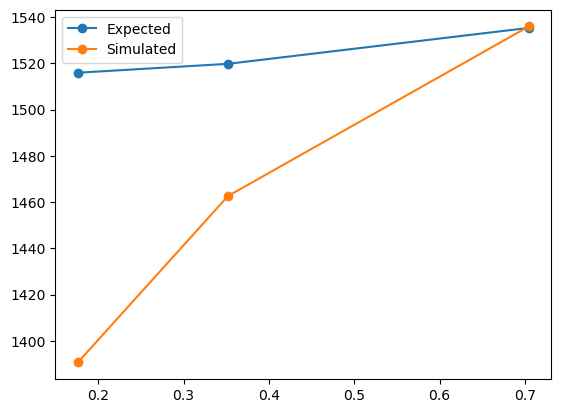

In [ ]:

dt_tilde_vals = np.array([0.5**(i + 1)* 1e-7 / t_0 for i in range(3)])
dt_vals = dt_tilde_vals * t_0
print(dt_vals)
print(dt_tilde_vals)
flux_vals = np.zeros_like(dt_tilde_vals)
for i, dt in enumerate(dt_vals):
  data = pd.read_csv(f"dt_{dt:0.2e}/real_csv_final.csv")
  left = data["left_heat_flux"].to_numpy()[0]
  right = data["right_heat_flux"].to_numpy()[0]
  mean = (left + np.abs(right)) / 2.0
  flux_vals[i] = mean
plt.figure()
plt.plot(dt_tilde_vals, q_wall(dt_tilde_vals, dx_tilde), '-o', label='Expected')
plt.plot(dt_tilde_vals, flux_vals, '-o', label='Simulated')
plt.legend()
plt.show()
